# Spatial quantification and plotting

Plot allocentric head direction, bearings towards fixed or moving ROIs, and spatial occupancy.

Set the recording inputs, load the streams, then run the angle and occupancy sections. Each recording uses its own clock, calibration and background image. Pose processing runs before trial selection.


In [1]:
# ===============================================================================
# 1 | Locate This Checkout and Refresh Project Imports After Source Changes
# ===============================================================================

from pathlib import Path
from runpy import run_path

# --- 1.1 | Locate src/ from the checkout root or any notebook subdirectory -------
source_root = next((
    candidate
    for parent in (Path.cwd(), *Path.cwd().parents)
    for candidate in (parent, parent / "src")
    if (candidate / "data_conduit").is_dir() and (candidate / "movement_figures").is_dir()
), None)
if source_root is None:
    raise FileNotFoundError("Open this notebook inside the data-conduit checkout.")

# --- 1.2 | Refresh cached project modules before importing the refactored API ----
# Load the bootstrap by file path: even a cached older package cannot shadow it.
# Rerun the following cells afterwards to rebuild data and figures consistently.
refresh_project_imports = run_path(
    str(source_root / "movement_figures" / "notebook_setup.py")
)["refresh_project_imports"]
source_root = refresh_project_imports(source_root)

# --- 1.3 | Import the analysis and plotting functions from this checkout ---------

from textwrap import fill

import matplotlib.pyplot as plt
import movement
import movement.kinematics as kin
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.figure import Figure
from movement.plots import plot_occupancy
from movement.utils.vector import compute_signed_angle_2d

from data_conduit.datastructures import slice_stream, slice_stream_for_trial
from data_conduit.refactor_qc.training_filter import filter_trials
from movement_figures.data_template.loading import (
    build_datastructure,
    prepare_pose,
)
from data_conduit.integrations.DLC.pose import pose_to_movement
from movement_figures.video import read_session_video_frame, resolve_static_roi
from movement_figures.timeseries_template.annotations import annotate_qc_timeseries

print(f"movement {movement.__version__}: {movement.__file__}")


movement 0.17.0: /home/sepi/anaconda3/envs/data-conduit-refactor/lib/python3.12/site-packages/movement/__init__.py


## Recording, processing and selection settings

`INCLUDE_SESSIONS` and `LEVEL_SELECTORS` choose recordings. `TRIAL_RANGE=(1, 8)` selects original trials 1–8 within each; `WINDOW` optionally restricts time.

`TRAINING_SPEC` enables the existing training rules. `EXCLUDE_LED_ON_SESSIONS=True` drops any recording with an ON-labelled trial in its original trial table. These labels record ON-event presence, not continuous LED state.

Use the printed recording IDs as calibration/ROI dictionary keys. The default static ROI is **north / top of the video**, the top-centre pixel position `((width - 1) / 2, 0)` of its first frame. This is a fixed target point, not a compass direction. To use a nosepoke, set `STATIC_ROI_NOSEPOKE` to its number and provide measured `(x, y)` pixel positions in `NOSEPOKE_POSITIONS_PX_BY_SESSION`; event port IDs alone do not specify image coordinates. Alternatively, `FIXED_ROI_PX_BY_SESSION` supplies measured point overrides when no nosepoke is selected. Coordinates must match the video tracked by DLC. Moving ROIs are optional `(time, space)` DataArrays with `space=["x", "y"]`, matching the full pose clock; missing moving-ROI entries omit that panel.


In [ ]:
# ===============================================================================
# 2| Choose Recordings, Tracked Landmarks, Processing and Trial Selection
# ===============================================================================

ROOT = Path("/media/sepi/Elements/PathIntegrationProtocol/BonsaiOutput/Training")
INCLUDE_SESSIONS = ("2026-06-21T093349Z",)                                    # Add actual recording-folder names, or use None for all selected folders.
LEVEL_NAMES = ("mouseID", "day")
LEVEL_SELECTORS = {}                                                          # Existing l0_selector/l1_selector filters restrict mice and days before reading.
SOURCES = ("trials", "dlc")                                                   # Trial columns annotate angles; DLC also reads its video-timestamp dependency.

INDIVIDUAL = "individual_0"
TRACKING_KEYPOINT = "body"                                                    # Occupancy counts this landmark's positions.
LEFT_EAR, RIGHT_EAR = "lear", "rear"
CAMERA_VIEW = "top_down"                                                      # Movement's ear convention for the camera above the animal.
REFERENCE_VECTOR = (1.0, 0.0)                                                 # Allocentric zero is image-right, unchanged by pixel/cm conversion.

CONFIDENCE_THRESHOLD = 0.9                                                    # Lower-confidence positions become NaN; None disables this operation.
MAX_GAP_FRAMES = None                                                         # None leaves missing samples unfilled; an integer limits the interpolated sample gap.
SMOOTHING_WINDOW = None                                                       # None disables the median; otherwise use an odd positive sample count.

SPATIAL_UNIT = "px"                                                           # Choose "px" or "cm" for positions, image edges and occupancy axes together.
PIXELS_PER_CM_BY_SESSION = {}                                                 # Fill with measured {recording_id: pixels_per_cm} before choosing "cm".
VIDEO_SUBDIR = "UndistortedVideoData"                                         # First-frame geometry must match DLC coordinates.
STATIC_ROI_NOSEPOKE = None                                                    # Set an integer port ID only when measured image coordinates are available below.
NOSEPOKE_POSITIONS_PX_BY_SESSION = {}                                          # {recording_id: {nosepoke_number: (x, y)}}; never infer pixels from event IDs.
FIXED_ROI_PX_BY_SESSION = {}                                                  # Optional measured {recording_id: (x, y)}; otherwise the static point is north/top.
MOVING_ROI_PX_BY_SESSION = {}                                                 # Fill with actual {recording_id: DataArray} on that recording's full pose clock.

TRAINING_SPEC = None                                                          # Optional existing refactor_qc training table; None applies no spreadsheet exclusions.
EXCLUDE_LED_ON_SESSIONS = False                                               # True removes a whole recording containing any original LED-ON trial.
TRIAL_RANGE = None                                                            # Inclusive original trial_index bounds, such as (1, 8); None keeps every remaining trial.
WINDOW = None                                                                 # Optional absolute (start, end) seconds, applied within each recording before plotting.
PLOT_MODE = "line"                                                         # "scatter" or "line"; lines break at NaNs, clock gaps and the +/-pi wrap.
TRACE_MAX_GAP_SECONDS = None                                                  # None detects recording gaps above three times the full-clock median interval.


## Load and inspect recordings

Inspect the printed identities and trial table before calculating measurements. Subsequent selections keep the matching recording ID on pose and trial data.


In [3]:
# ===============================================================================
# 3| Load the Selected Recordings and Apply the Existing Training Rules
# ===============================================================================

# === 1| Configure Directory Selection and Read the Requested Streams ============

data = build_datastructure(
    ROOT,
    level_names=LEVEL_NAMES,
    streams=SOURCES,
    include=INCLUDE_SESSIONS,                                                 # Folder-name selection occurs before the readers open recording files.
    **LEVEL_SELECTORS,
)
streams = data.load()                                                         # Returns the existing stream mapping, not a new figure-result class.
all_trials = streams["trials"]
selected_trials = all_trials.copy()                                           # Keep the original rows available for whole-session LED checks.

# === 2| Apply Optional Training Rules Without Losing Recording Identity ==========

if TRAINING_SPEC is not None:
    session_names = {recording_id: ref.path.name for recording_id, ref in data.sessions.items()}
    selected_trials["session_name"] = selected_trials["session"].map(session_names)  # Add leaf names for the spreadsheet; retain full IDs in session.
    training_rules = TRAINING_SPEC.rename(columns={"session": "session_name"})
    selected_trials = filter_trials(
        selected_trials, training_rules,
        session_column="session_name", report=False,                          # Existing mouse+leaf-name rules; the original recording identity stays intact.
    )

# === 3| Inspect the Loaded Recording IDs and the Trial Rows Available to Select ==

for session_id, session_ref in data.sessions.items():
    print(session_id, "->", session_ref.path)                                 # Use this exact ID as the calibration/ROI dictionary key.
display(selected_trials)



                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  

                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  
2026-06-21T093349Z -> /media/sepi/Elements/PathIntegrationProtocol/BonsaiOutput/Training/MR_M01569515/Day21/2026-06-21T093349Z


,trial_index,start_time,end_time,start_inclusive,end_inclusive,first_event_index,last_event_index,tz_triggered_time,tz_available_time,ChosenPort,...,outbound_end_time,outbound_start_inclusive,outbound_end_inclusive,inbound_start_time,inbound_end_time,inbound_start_inclusive,inbound_end_inclusive,session,mouseID,day
0,1,5633.836992,5667.029120,True,True,1,12,5663.198976,5640.910976,0,...,5663.198976,True,True,5663.198976,5667.029120,True,True,2026-06-21T093349Z,MR_M01569515,Day21
1,2,5667.029120,5681.075968,False,True,13,27,5678.849984,5675.540992,0,...,5678.849984,False,True,5678.849984,5681.075968,True,True,2026-06-21T093349Z,MR_M01569515,Day21
2,3,5681.075968,5695.245088,False,True,28,42,5693.349984,5690.241984,0,...,5693.349984,False,True,5693.349984,5695.245088,True,True,2026-06-21T093349Z,MR_M01569515,Day21
3,4,5695.245088,5709.933824,False,True,43,56,5707.698976,5697.756000,0,...,5707.698976,False,True,5707.698976,5709.933824,True,True,2026-06-21T093349Z,MR_M01569515,Day21
4,5,5709.933824,5721.442080,False,True,57,71,5719.708992,5719.392000,0,...,5719.708992,False,True,5719.708992,5721.442080,True,True,2026-06-21T093349Z,MR_M01569515,Day21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,102,7311.543744,7328.291776,False,True,1409,1422,7325.601984,7319.292384,0,...,7325.601984,False,True,7325.601984,7328.291776,True,True,2026-06-21T093349Z,MR_M01569515,Day21
102,103,7328.291776,7349.316480,False,True,1423,1436,7344.304000,7335.678976,-1,...,7344.304000,False,True,7344.304000,7349.316480,True,True,2026-06-21T093349Z,MR_M01569515,Day21
103,104,7349.316480,7370.981504,False,True,1437,1449,7365.952992,7356.648000,-1,...,7365.952992,False,True,7365.952992,7370.981504,True,True,2026-06-21T093349Z,MR_M01569515,Day21
104,105,7370.981504,7417.264352,False,True,1450,1462,7414.952992,7379.677984,0,...,7414.952992,False,True,7414.952992,7417.264352,True,True,2026-06-21T093349Z,MR_M01569515,Day21


## Allocentric direction and ROI bearings

Allocentric direction is measured from `REFERENCE_VECTOR` to the head-forward vector. The default zero points right; positive angles are clockwise in image coordinates with y down.

Egocentric bearing is the angle from head-forward to **ROI position − ear midpoint**. Zero means straight ahead. A moving ROI's heading is irrelevant. Missing/coincident ears or an ROI at the head centre produce undefined angles.

Choose scatter or line display. Lines break at missing samples, acquisition gaps and the ±π wrap.

The plotting call sets `row_duration_s=25.0`, matching the kinematics figures.
Each time interval has a full-width panel for every supplied angle; changing
this duration changes the layout without changing the selected trials.


In [4]:
# ===============================================================================
# 4| Draw Already-Selected Head Angles on Their Recording Clock
# ===============================================================================


def plot_head_angles(
    angles: xr.Dataset,                                                       # One recording's selected angles; excluded samples should remain NaN on its clock.
    trials: pd.DataFrame | None = None,                                       # Optional matching trial rows; the function never chooses them.
    *,
    row_duration_s: float = 25.0,                                             # Display seconds per row, matching the kinematics figure layout.
    mode: str = "scatter",                                                    # Draw measured points or measured lines, with no additional angle calculation.
    max_gap_seconds: float | None = None,                                     # Caller supplies a gap threshold from the full recording clock.
    title: str = "Head direction",
    color: str = "#5b4b9a",
    marker_size: float = 2.5,
    figsize: tuple[float, float] | None = None,
) -> tuple[Figure, np.ndarray]:
    """
    Draw supplied angles in successive time rows, with matching trial annotations.

    Parameters
    ----------
    angles : xarray.Dataset
        Angle variables in radians, each with only a time dimension containing
        increasing recording-clock seconds. A variable's ``label`` attribute
        supplies its readable axis name. NaNs mark missing or excluded samples.
    trials : pandas.DataFrame | None
        Already-selected trial rows from the same recording and clock. None
        omits the existing Q_C trial annotations. Raw events are not required.
    row_duration_s : float
        Positive number of recording seconds displayed across every row.
        Each time interval has one full-width panel per angle. The final
        interval retains this width, with unused time shaded.
    mode : str
        ``"scatter"`` draws measured points; ``"line"`` joins adjacent valid
        measurements and breaks at NaNs, long clock gaps and jumps above pi.
    max_gap_seconds : float | None
        Positive gap threshold in seconds. None disables clock-gap detection;
        missing samples and circular wrapping still break lines.
    title, color : str
        Figure heading and Matplotlib measurement colour.
    marker_size : float
        Positive scatter-marker size in points. Does not alter measured angles.
    figsize : tuple[float, float] | None
        Figure width/height in inches. None allocates 2.7 inches per displayed
        panel so longer recordings gain rows without compressing their traces.

    Returns
    -------
    tuple[matplotlib.figure.Figure, numpy.ndarray]
        Figure and one-dimensional axes array, ordered by time interval and
        then by angle variable. Trial selection and measured angles are
        unchanged; the function returns the figure without calling ``show``.
    """

    # === 1| Check the Supplied Angle Clock and Drawing Controls ==================

    if not np.isfinite(row_duration_s) or row_duration_s <= 0:
        raise ValueError("row_duration_s must be finite and positive.")
    if mode not in ("scatter", "line"):
        raise ValueError("mode must be 'scatter' or 'line'.")
    if not angles.data_vars or angles.sizes.get("time", 0) == 0:
        raise ValueError("angles must contain angle variables and time samples.")
    times = np.asarray(angles.time, dtype=float)
    if not np.isfinite(times).all() or np.any(np.diff(times) <= 0):
        raise ValueError("Angle timestamps must be finite and strictly increasing.")
    if max_gap_seconds is not None and (not np.isfinite(max_gap_seconds) or max_gap_seconds <= 0):
        raise ValueError("max_gap_seconds must be finite and positive, or None.")
    if not np.isfinite(marker_size) or marker_size <= 0:
        raise ValueError("marker_size must be finite and positive.")
    for name, angle in angles.data_vars.items():
        if angle.dims != ("time",):
            raise ValueError(f"{name} must have only the time dimension.")

    # === 2| Divide the Supplied Recording Clock into Equal-Duration Rows =========

    start, end = float(times[0]), float(times[-1])
    row_count = max(1, int(np.ceil((end - start) / row_duration_s)))
    # Avoid an extra empty row when a boundary is rounded in floating-point time.
    while row_count > 1 and start + (row_count - 1) * row_duration_s >= end:
        row_count -= 1
    angle_count = len(angles.data_vars)
    if figsize is None:
        figsize = (13, 2.7 * row_count * angle_count)
    fig, grid = plt.subplots(
        row_count * angle_count, 1, figsize=figsize,
        squeeze=False, sharey=True, layout="constrained",
    )  # Each panel keeps its own time limits; every angle shares the same y scale.
    axes = grid[:, 0]
    legend_handles = {}

    # === 3| Draw Each Time Row, Keeping One Full-Width Panel per Angle ============

    for row_number in range(row_count):
        row_start = start + row_number * row_duration_s
        row_stop = row_start + row_duration_s
        selected_stop = min(row_stop, end)
        row_angles = angles.sel(time=slice(row_start, selected_stop))
        row_times = np.asarray(row_angles.time, dtype=float)

        for angle_number, (name, angle) in enumerate(row_angles.data_vars.items()):
            ax = axes[row_number * angle_count + angle_number]
            values = np.asarray(angle, dtype=float)
            if mode == "scatter":
                ax.plot(row_times, values, ".", ms=marker_size, color=color)
            else:
                # Keep both observations around angle wraps and acquisition gaps.
                breaks = np.abs(np.diff(values)) > np.pi
                if max_gap_seconds is not None:
                    breaks |= np.diff(row_times) > max_gap_seconds
                split_positions = np.flatnonzero(breaks) + 1
                break_times = (row_times[split_positions - 1] + row_times[split_positions]) / 2
                line_times = np.insert(row_times, split_positions, break_times)
                line_values = np.insert(values, split_positions, np.nan)
                ax.plot(line_times, line_values, color=color, linewidth=1.0)

            # --- Label the measurement and clip annotations to this time row. ---
            ax.set_ylabel(fill(angle.attrs.get("label", name) + " (rad)", width=28))
            ax.set_ylim(-np.pi, np.pi)
            ax.set_yticks([-np.pi, 0, np.pi], ["−π", "0", "π"])
            ax.grid(axis="y", alpha=0.2)
            if trials is not None and not trials.empty and selected_stop > row_start:
                annotations = annotate_qc_timeseries(
                    ax, trials, window=(row_start, selected_stop), legend=False,
                )
                for handle in annotations.legend_handles:
                    legend_handles.setdefault(handle.get_label(), handle)

            # Preserve the same seconds-per-row scale, including the final tail.
            if selected_stop < row_stop:
                ax.axvspan(selected_stop, row_stop, color="0.94", zorder=0)
            ax.set_xlim(row_start, row_stop)
            ax.set_xlabel("Recording time (s)")
            ax.ticklabel_format(axis="x", style="plain", useOffset=False)
            ax.set_title(f"Row {row_number + 1}", loc="left", fontsize=10)

    # === 4| Return the Figure with One Legend Shared by All Time Rows ============

    fig.suptitle(title)
    if legend_handles:
        fig.legend(handles=list(legend_handles.values()), loc="outside lower center", ncol=4)
    return fig, axes


In [5]:
# ===============================================================================
# 5| Prepare Measurements and Reusable Figure Inputs for Each Recording
# ===============================================================================

def prepare_spatial_sessions(
    data, streams: dict, 
    selected_trials: pd.DataFrame, 
    *,
    individual: str, 
    tracking_keypoint: str, 
    left_ear_name: str, 
    right_ear_name: str,
    camera_view: str, 
    reference_vector: tuple[float, float],
    confidence_threshold: float | None, 
    max_gap_frames: int | None,
    smoothing_window: int | None, 
    spatial_unit: str,
    pixels_per_cm_by_session: dict, 
    fixed_roi_px_by_session: dict,
    static_roi_nosepoke: int | None, 
    nosepoke_positions_px_by_session: dict,
    moving_roi_px_by_session: dict, 
    exclude_led_on_sessions: bool,
    trial_range: tuple[int, int] | None, 
    window: tuple[float, float] | None,
    video_subdir: str,
) -> dict[str, dict]:
    """Prepare selected head angles, positions and first frames per recording.

    Parameters
    ----------
    data : DataStructure
        Loaded recording collection; ``sessions`` maps recording IDs to paths.
    streams : dict
        Loaded trials and aligned ``dlc:position``/``dlc:confidence`` streams.
        Original trial rows provide whole-recording LED exclusions.
    selected_trials : pandas.DataFrame
        Trial rows after optional training rules; original indices and endpoint
        inclusion flags remain intact.
    individual : str
        Animal label assigned to this DLC export.
    tracking_keypoint : str
        Required landmark later used for occupancy.
    left_ear_name, right_ear_name : str
        Landmark labels defining head direction and the ear-midpoint origin.
    camera_view : str
        Movement's camera convention; ``top_down`` means image y points down.
    reference_vector : tuple[float, float]
        Nonzero image direction defining allocentric zero, independent of ROI.
    confidence_threshold : float | None
        Minimum accepted DLC confidence; None disables confidence masking.
    max_gap_frames : int | None
        Maximum missing-sample gap to interpolate; None leaves gaps unfilled.
    smoothing_window : int | None
        Odd median-filter sample count; None leaves positions unsmoothed.
    spatial_unit : str
        ``px`` or ``cm``; all point coordinates share the same spatial scale.
    pixels_per_cm_by_session : dict
        Positive measured pixel/cm calibration keyed by recording ID; required
        for every recording when spatial_unit is ``cm``.
    fixed_roi_px_by_session : dict
        Optional measured pixel points keyed by recording ID. Missing points
        default to north/top of the first frame when no nosepoke is selected.
    static_roi_nosepoke : int | None
        Number of a measured nosepoke; None uses point overrides or north/top.
    nosepoke_positions_px_by_session : dict
        Recording ID -> {nosepoke number: (x, y) pixels}. Required for a selected
        nosepoke; event port numbers do not determine image geometry.
    moving_roi_px_by_session : dict
        Optional recording ID -> (time, space) ROI positions in pixels with an
        exactly matching full pose clock and space=['x', 'y'].
    exclude_led_on_sessions : bool
        Exclude recordings with any original LED-ON-labelled trial.
    trial_range : tuple[int, int] | None
        Inclusive original trial-index bounds; None keeps all selected rows.
    window : tuple[float, float] | None
        Absolute recording-time bounds intersected with selected trials. None
        keeps the full selected trial union.
    video_subdir : str
        Video folder whose first-frame coordinates match DLC tracking.

    Returns
    -------
    dict[str, dict]
        Per-recording positions, selected trials, scale, full-clock head angles,
        visible angle extent, first RGB frame, video path and scaled static ROI
        point/label. No figures are created. Missing samples and excluded time
        intervals remain NaN; recordings without selected pose are omitted.
    """
    spatial_inputs = {}                                                           # Plain selected arrays and trial tables are reused by the later occupancy cell.
    pose_sessions = []                                                            # Optional DLC may be absent from some or all selected recordings.
    if "dlc:position" in streams and "dlc:confidence" in streams:
        pose_sessions = pd.unique(streams["dlc:position"].session.values).tolist()

    for session_id, session_ref in data.sessions.items():

        # === 1| Apply Whole-Recording LED Exclusion Before the Trial Range ===========

        original_trials = slice_stream(streams["trials"], selectors={"session": session_id})
        if exclude_led_on_sessions and original_trials["LED"].eq("ON").any():
            print(f"{session_id}: skipped because the original trial table contains LED ON.")
            continue

        trials = slice_stream(selected_trials, selectors={"session": session_id})
        if trial_range is not None:
            trials = slice_stream(trials, selectors={"trial_index": slice(*trial_range)})
        if trials.empty:
            print(f"{session_id}: no trials remain after the selected rules.")
            continue

        if session_id not in pose_sessions:
            print(f"{session_id}: skipped because no aligned pose was loaded.")
            continue

        # === 2| Convert and Process Only This Recording's Aligned DLC Arrays =========

        raw_pose = pose_to_movement(
            slice_stream(streams["dlc:position"], selectors={"session": session_id}),
            slice_stream(streams["dlc:confidence"], selectors={"session": session_id}),
            individual=individual,                                                # Label the one animal in this DLC export; conversion preserves the acquired clock.
        )
        pose = prepare_pose(
            raw_pose,
            confidence_threshold=confidence_threshold,
            max_gap_frames=max_gap_frames,
            smoothing_window=smoothing_window,                                    # Filtering uses this full recording; it never joins separate trial slices.
        )
        position_px = pose.position.sel(individual=individual, drop=True)

        # === 3| Resolve This Recording's Spatial Scale and Selected Time Samples =====

        if spatial_unit not in ("px", "cm"):
            raise ValueError("spatial_unit must be 'px' or 'cm'.")
        spatial_scale = 1.0
        if spatial_unit == "cm":
            pixels_per_cm = pixels_per_cm_by_session.get(session_id)
            if pixels_per_cm is None or not np.isfinite(pixels_per_cm) or pixels_per_cm <= 0:
                raise ValueError(f"{session_id}: supply a positive measured pixels-per-cm calibration.")
            spatial_scale = 1.0 / float(pixels_per_cm)                            # Apply the same calibration to position, ROI coordinates and image edges.

        keep = xr.zeros_like(position_px.time, dtype=bool)
        for _, trial in trials.iterrows():
            trial_position = slice_stream_for_trial(
                position_px, trial, time_coord="time",                            # The row supplies both recording identity and its numeric time bounds.
            )
            keep |= position_px.time.isin(trial_position.time)                    # The trial row supplies its bounds and endpoint inclusion.
        if window is not None:
            window_position = slice_stream(position_px, selectors={"time": slice(*window)})
            keep &= position_px.time.isin(window_position.time)                   # Intersect the trial selection with the explicit clock window.
        if not bool(keep.any()):
            print(f"{session_id}: no pose samples lie inside the selected intervals.")
            continue
        position = (position_px * spatial_scale).where(keep)                      # Retained NaNs stop lines crossing an excluded trial or interval.
        position.attrs["units"] = spatial_unit

        # === 4| Resolve the Static Target from This Recording's First Video Frame =====

        background_frame, video_path = read_session_video_frame(
            session_ref.path, video_subdir=video_subdir,
        )
        fixed_roi_px, fixed_roi_label = resolve_static_roi(
            background_frame,
            roi_px=fixed_roi_px_by_session.get(session_id),
            nosepoke=static_roi_nosepoke,
            nosepoke_positions_px=nosepoke_positions_px_by_session.get(session_id),
        )
        print(f"{session_id}: static ROI = {fixed_roi_label}, pixels {fixed_roi_px.tolist()}")

        # === 5| Define the Head Origin and Reject Missing or Coincident Ears =========

        for landmark in (left_ear_name, right_ear_name, tracking_keypoint):
            if landmark not in position.keypoint:
                raise ValueError(f"{session_id}: missing tracked keypoint {landmark!r}.")
        reference = np.asarray(reference_vector, dtype=float)
        if reference.shape != (2,) or not np.isfinite(reference).all() or np.linalg.norm(reference) == 0:
            raise ValueError("reference_vector must be a finite, nonzero x/y direction.")
        left_ear = position.sel(keypoint=left_ear_name, drop=True)
        right_ear = position.sel(keypoint=right_ear_name, drop=True)
        head_centre = (left_ear + right_ear) / 2                                  # Both ROI direction vectors start midway between the ears.
        ear_distance = np.sqrt(((left_ear - right_ear) ** 2).sum("space", skipna=False))
        valid_head = np.isfinite(ear_distance) & (ear_distance > 0)

        # === 5.1| Call Movement Directly for Allocentric Heading and Head Direction ====

        allocentric = kin.compute_forward_vector_angle(
            position,
            left_keypoint=left_ear_name,
            right_keypoint=right_ear_name,
            reference_vector=reference_vector,                                    # This external direction defines zero, independent of the animal's body.
            camera_view=camera_view,                                              # Top-down ear labels determine which perpendicular direction points forwards.
        ).where(valid_head)
        head_forward = kin.compute_head_direction_vector(
            position,
            left_keypoint=left_ear_name,
            right_keypoint=right_ear_name,
            camera_view=camera_view,
        ).where(valid_head)
        head_angles = xr.Dataset({"allocentric_heading": allocentric})
        head_angles.allocentric_heading.attrs["label"] = "Allocentric head direction"

        # === 6| Measure Bearing from the Head Towards the Actual Fixed ROI ===========

        # The resolver already validated either a measured point or north/top.
        fixed_roi = xr.DataArray(
            fixed_roi_px * spatial_scale, dims="space", coords={"space": ["x", "y"]},
        )
        to_fixed_roi = fixed_roi - head_centre  # Bearing changes with head position.
        fixed_distance = np.sqrt((to_fixed_roi ** 2).sum("space", skipna=False))
        fixed_bearing = compute_signed_angle_2d(head_forward, to_fixed_roi)
        head_angles["fixed_roi_bearing"] = fixed_bearing.where(valid_head & (fixed_distance > 0))
        head_angles.fixed_roi_bearing.attrs["label"] = f"Bearing towards {fixed_roi_label}"

        # === 7| Align Actual Moving-ROI Positions and Measure Their Bearing ===========

        moving_roi_px = moving_roi_px_by_session.get(session_id)
        if moving_roi_px is not None:
            if not isinstance(moving_roi_px, xr.DataArray) or moving_roi_px.dims != ("time", "space"):
                raise ValueError(f"{session_id}: moving ROI needs dimensions (time, space).")
            if list(moving_roi_px.space.values) != ["x", "y"]:
                raise ValueError(f"{session_id}: moving ROI needs space=['x', 'y'].")
            moving_roi = moving_roi_px * spatial_scale
            moving_roi, aligned_head = xr.align(moving_roi, head_centre, join="exact")  # Reject mismatched clocks; never silently interpolate another animal.
            to_moving_roi = moving_roi - aligned_head                             # Its changing position is relevant; its own heading is not an input.
            moving_distance = np.sqrt((to_moving_roi ** 2).sum("space", skipna=False))
            moving_bearing = compute_signed_angle_2d(head_forward, to_moving_roi)
            valid_roi = np.isfinite(to_moving_roi).all("space") & (moving_distance > 0)
            head_angles["moving_roi_bearing"] = moving_bearing.where(valid_head & valid_roi)
            head_angles.moving_roi_bearing.attrs["label"] = "Bearing towards moving ROI"
        else:
            print(f"{session_id}: moving ROI panel omitted; no aligned position data supplied.")
        for name in head_angles:
            head_angles[name].attrs["units"] = "rad"                              # Uniform position scaling changes distances but not angles.

        # === 8| Return Measurements and Matching Image Geometry for Plotting =========

        selected_times = position.time.where(keep, drop=True)
        selected_extent = slice(float(selected_times.min()), float(selected_times.max()))
        spatial_inputs[session_id] = {
            "position": position,
            "trials": trials,
            "spatial_scale": spatial_scale,
            "head_angles": head_angles,
            "visible_angles": head_angles.sel(time=selected_extent),
            "background_frame": background_frame,
            "video_path": video_path,
            "fixed_roi": fixed_roi_px * spatial_scale,
            "fixed_roi_label": fixed_roi_label,
        }  # Selected NaNs remain on the full clock; image, points and target share one scale.
    return spatial_inputs


def plot_session_head_angles(
    spatial_inputs: dict[str, dict], *, row_duration_s: float,
    mode: str = "scatter",
    max_gap_seconds: float | None = None,
) -> dict[str, tuple[Figure, np.ndarray]]:
    """Draw one head-angle figure for each prepared recording.

    Parameters
    ----------
    spatial_inputs : dict[str, dict]
        Outputs of prepare_spatial_sessions containing positions, visible angles
        and selected trials for each independent recording.
    row_duration_s : float
        Positive number of seconds per displayed time row, passed unchanged
        to plot_head_angles. It does not restrict the supplied trial data.
    mode : str
        ``scatter`` draws samples; ``line`` joins valid adjacent angles and
        breaks at missing values, recording gaps and the +/-pi wrap.
    max_gap_seconds : float | None
        Positive line-gap limit in seconds. None calculates three times each
        recording's full-clock median sample interval before drawing.

    Returns
    -------
    dict[str, tuple[matplotlib.figure.Figure, numpy.ndarray]]
        Recording ID -> figure and one-dimensional axes ordered by time row
        and then angle. The function
        leaves measurement data unchanged and does not call show.
    """
    # === 1| Derive Gap Limits from Each Untrimmed Recording Clock ================
    figures = {}
    for session_id, selected in spatial_inputs.items():
        clock_gaps = np.diff(np.asarray(selected["position"].time, dtype=float))
        gap = max_gap_seconds
        if gap is None and clock_gaps.size:
            gap = 3 * float(np.median(clock_gaps))

        # === 1.1| Pass Only This Recording's Angles and Trial Annotations =========
        figures[session_id] = plot_head_angles(
            selected["visible_angles"], selected["trials"],
            row_duration_s=row_duration_s, mode=mode,
            max_gap_seconds=gap,
            title=f"{session_id} · selected-trial head direction",
        )
    return figures


# === 6| Prepare Once, Then Redraw from the Returned Inputs =======================
spatial_inputs = prepare_spatial_sessions(
    data, streams, selected_trials,
    individual=INDIVIDUAL, tracking_keypoint=TRACKING_KEYPOINT,
    left_ear_name=LEFT_EAR, right_ear_name=RIGHT_EAR,
    camera_view=CAMERA_VIEW, reference_vector=REFERENCE_VECTOR,
    confidence_threshold=CONFIDENCE_THRESHOLD, max_gap_frames=MAX_GAP_FRAMES,
    smoothing_window=SMOOTHING_WINDOW, spatial_unit=SPATIAL_UNIT,
    pixels_per_cm_by_session=PIXELS_PER_CM_BY_SESSION,
    fixed_roi_px_by_session=FIXED_ROI_PX_BY_SESSION,
    static_roi_nosepoke=STATIC_ROI_NOSEPOKE,
    nosepoke_positions_px_by_session=NOSEPOKE_POSITIONS_PX_BY_SESSION,
    moving_roi_px_by_session=MOVING_ROI_PX_BY_SESSION,
    exclude_led_on_sessions=EXCLUDE_LED_ON_SESSIONS,
    trial_range=TRIAL_RANGE, window=WINDOW, video_subdir=VIDEO_SUBDIR,
)
head_angles_by_session = {
    session_id: selected["head_angles"] for session_id, selected in spatial_inputs.items()
}
angle_figures = plot_session_head_angles(
    spatial_inputs, row_duration_s=25.0,  # Display seconds per row, as in kinematics.
    mode=PLOT_MODE, max_gap_seconds=TRACE_MAX_GAP_SECONDS,
)
plt.show()


2026-06-21T093349Z: static ROI = North / top of video, pixels [809.5, 0.0]
2026-06-21T093349Z: moving ROI panel omitted; no aligned position data supplied.


## Occupancy of selected trials, outbound and inbound paths

`plot_occupancy` counts valid position samples in rectangular bins—not seconds or probabilities. Empty bins are transparent; bins are not clipped to the arena circle.

Outbound excludes the target sample; inbound includes it. Outer trial inclusion is preserved. Trials lacking a valid target time appear only in the selected-trials panel.

All panels within a recording share bin edges and colour limits. With 30 bins per axis, widths are `(xmax−xmin)/30` and `(ymax−ymin)/30`; the cells need not be square. Their dimensions are printed. `OCCUPANCY_VMAX` changes colour scaling only.

Pose and background image must use the same camera geometry and spatial scale. The `UndistortedVideoData` name alone does not verify lens correction.


In [6]:
# ===============================================================================
# 6| Control Occupancy Bins, Shared Colour Limits and Matching Video Backgrounds
# ===============================================================================

OCCUPANCY_BINS = 30                                                           # Thirty bins along x and y form 30 x 30 rectangular cells, not a circular mask.
OCCUPANCY_VMAX = 100.0                                                        # Display ceiling in samples/bin; None uses this recording's largest observed count.
OCCUPANCY_ALPHA = 0.70                                                        # Opacity of occupied cells; zero-count cells remain completely transparent.
ARENA_RANGE_PX_BY_SESSION = {}                                                # Optional measured {recording_id: ((xmin, xmax), (ymin, ymax))}; absent means full frame.


In [7]:
# ===============================================================================
# 7| Overlay Already-Selected Occupancy Arrays on One Matching Video Frame
# ===============================================================================

def plot_spatial_occupancy(
    points: dict[str, xr.DataArray],                                          # Panel names mapped to already-selected positions from one recording.
    background_frame: np.ndarray,                                             # Matching RGB/RGBA image in the same raw/corrected camera space.
    *,
    frame_extent: tuple[float, float, float, float],                          # Image edges after the same pixel/cm conversion as positions.
    spatial_unit: str = "px",
    fixed_roi: np.ndarray | None = None,
    fixed_roi_label: str = "Static ROI",
    bins: int = 30,
    arena_range: tuple[tuple[float, float], tuple[float, float]] | None = None,
    vmax: float | None = None,
    alpha: float = 0.70,
    title: str = "Spatial occupancy",
    figsize: tuple[float, float] | None = None,
) -> tuple[Figure, np.ndarray, dict[str, dict[str, np.ndarray]]]:
    """Overlay supplied point arrays on a matching image using rectangular bins.

    Parameters
    ----------
    points : dict[str, xarray.DataArray]
        Panel labels mapped to preselected arrays with dimensions (time, space),
        space=['x', 'y'], and coordinates in spatial_unit. Empty panels are allowed.
    background_frame : numpy.ndarray
        Matching RGB/RGBA video frame, already corrected upstream if required.
    frame_extent : sequence[float]
        Image (left, right, bottom, top) edges in the same units as points;
        image coordinates have bottom > top because y increases downwards.
    spatial_unit : str
        'px' or 'cm'; coordinates and image edges must already be converted.
    fixed_roi : numpy.ndarray | None
        Optional static target (x, y) in spatial_unit, already scaled exactly as
        points and frame_extent. None omits the gold target marker.
    fixed_roi_label : str
        Human-readable target name, for example "North / top of video".
    bins : int
        Positive number of rectangular bins on each spatial axis.
    arena_range : sequence | None
        Optional ((xmin, xmax), (ymin, ymax)) bounds; None uses the frame edges.
    vmax : float | None
        Colour ceiling in samples/bin. None shares the largest observed count.
    alpha : float
        Overlay opacity between zero and one. Zero-count cells stay transparent.
    title : str
        Overall figure title.
    figsize : tuple[float, float] | None
        Figure width/height in inches. None allocates 5.2 inches per panel.

    Returns
    -------
    tuple[matplotlib.figure.Figure, numpy.ndarray, dict]
        Figure, axes array, and histogram dictionaries for nonempty panels.
        Histograms contain h[x_bin, y_bin], xedges and yedges; counts are unchanged.
        Empty panels still display the matching frame. The function does not
        select trials, rescale positions, correct the video, normalise counts or
        call show. Zero-bin masking and the colour ceiling affect drawing only.
    """
    #=== 1| Check point arrays, image edges and the histogram controls ============

    if not points:
        raise ValueError("Supply at least one named occupancy panel.")
    if spatial_unit not in ("px", "cm"):
        raise ValueError("spatial_unit must be 'px' or 'cm'.")
    if isinstance(bins, (bool, np.bool_)) or not isinstance(bins, (int, np.integer)) or bins < 1:
        raise ValueError("bins must be a positive integer.")
    if vmax is not None and (not np.isfinite(vmax) or vmax <= 0):
        raise ValueError("vmax must be finite and positive, or None.")
    if not np.isfinite(alpha) or not 0 <= alpha <= 1:
        raise ValueError("alpha must be between zero and one.")
    frame = np.asarray(background_frame)
    if frame.ndim != 3 or frame.shape[2] not in (3, 4) or min(frame.shape[:2]) == 0:
        raise ValueError("background_frame must be a nonempty RGB or RGBA image.")
    extent = np.asarray(frame_extent, dtype=float)
    if extent.shape != (4,) or not np.isfinite(extent).all() or extent[0] >= extent[1] or extent[3] >= extent[2]:
        raise ValueError("frame_extent needs increasing x edges and downward image y edges.")
    if fixed_roi is not None:
        fixed_roi = np.asarray(fixed_roi, dtype=float)
        if fixed_roi.shape != (2,) or not np.isfinite(fixed_roi).all():
            raise ValueError("fixed_roi must contain two finite coordinates.")
    for label, point in points.items():
        if point.dims != ("time", "space") or list(point.space.values) != ["x", "y"]:
            raise ValueError(f"{label}: expected (time, space) with space=['x', 'y'].")

    # === 2| Give Every Panel the Same Rectangular Bin Edges and Image Extent =====

    # Frame edges are left/right/bottom/top; histogram bounds need low/high x/y.
    # Using these limits keeps empty space in the rectangular camera view rather
    # than shrinking bins to whichever positions happened to be visited.

    limits = np.asarray(arena_range) if arena_range is not None else np.array([
        [extent[0], extent[1]], [extent[3], extent[2]],
    ])
    if limits.shape != (2, 2) or not np.isfinite(limits).all() or np.any(limits[:, 0] >= limits[:, 1]):
        raise ValueError("arena_range must contain increasing finite x and y bounds.")
    if figsize is None:
        figsize = (5.2 * len(points), 5.8)                                    # Keep the same width for each supplied occupancy panel.
    figure, grid = plt.subplots(
        1, len(points), squeeze=False, sharex=True, sharey=True,
        figsize=figsize, layout="constrained",
    )
    axes = grid[0]
    cmap = plt.get_cmap("magma").with_extremes(bad=(0, 0, 0, 0))              # Masked zero-count cells reveal the video completely.
    histograms, meshes = {}, []
    observed_max = 0.0

    #=== 3| Let movement compute each histogram and hide only its empty cells =====

    for ax, (label, point) in zip(axes, points.items()):
        ax.imshow(frame, origin="upper", extent=extent, zorder=0)
        finite = point.where(np.isfinite(point).all("space"), drop=True)      # A histogram sample requires both finite x and y coordinates.
        if finite.sizes["time"]:
            _, _, histogram = plot_occupancy(
                finite, ax=ax, bins=bins, range=limits,
                cmap=cmap, alpha=alpha, zorder=1,                             # Shared binning; opacity changes display, never counts.
            )
            histograms[label] = histogram
            observed_max = max(observed_max, float(histogram["h"].max()))
            mesh = ax.collections[-1]
            if mesh.colorbar is not None:
                mesh.colorbar.remove()                                        # Replace movement's panel keys with one common colourbar.
            mesh.set_array(np.ma.masked_equal(histogram["h"].T, 0))           # Histogram axes are x/y; the drawing uses transposed y/x values.
            meshes.append(mesh)                                               # Histogram axes are x/y; the drawn mesh uses y/x order.
        else:
            ax.text(0.5, 0.5, "No valid samples", transform=ax.transAxes, ha="center")
        # === 3.1| Identify the Same Static Target Used by the Bearing Panel =======
        if fixed_roi is not None:
            ax.scatter(*fixed_roi, marker="*", s=110, color="gold", edgecolor="black", zorder=4)
            ax.text(0.02, 0.98, fixed_roi_label, transform=ax.transAxes, va="top",
                    color="gold", fontsize=9,
                    bbox={"facecolor": "black", "alpha": 0.65, "edgecolor": "none"})
        ax.set_xlim(*limits[0])
        ax.set_ylim(limits[1, 1], limits[1, 0])                               # Display image y increasing downwards in either unit.
        ax.set_aspect("equal")
        ax.set_title(label)
        ax.set_xlabel(f"x ({spatial_unit})")
    axes[0].set_ylabel(f"y ({spatial_unit})")

    #=== 4| Share the colour ceiling and return untouched histogram counts ========

    ceiling = float(vmax) if vmax is not None else max(1.0, observed_max)
    norm = Normalize(vmin=0, vmax=ceiling)
    for mesh in meshes:
        mesh.set_norm(norm)
    # An independent mappable keeps the colour key opaque while the video overlay
    # remains translucent. A pointed end signals values above a chosen ceiling.
    colourbar = figure.colorbar(
        ScalarMappable(norm=norm, cmap=cmap), ax=list(axes), orientation="horizontal",
        fraction=0.06, pad=0.09, extend="max" if observed_max > ceiling else "neither",
    )
    colourbar.set_label("Valid position samples / bin")
    figure.suptitle(title)
    return figure, axes, histograms


2026-06-21T093349Z: 106/106 retained rows have usable target times before the optional window intersection.
Background: /media/sepi/Elements/PathIntegrationProtocol/BonsaiOutput/Training/MR_M01569515/Day21/2026-06-21T093349Z/UndistortedVideoData/Training_MR_M01569515_Day21_093349Z.avi (first frame)
Selected trials: bin width 54 px; bin height 42 px
Outbound: bin width 54 px; bin height 42 px
Inbound: bin width 54 px; bin height 42 px


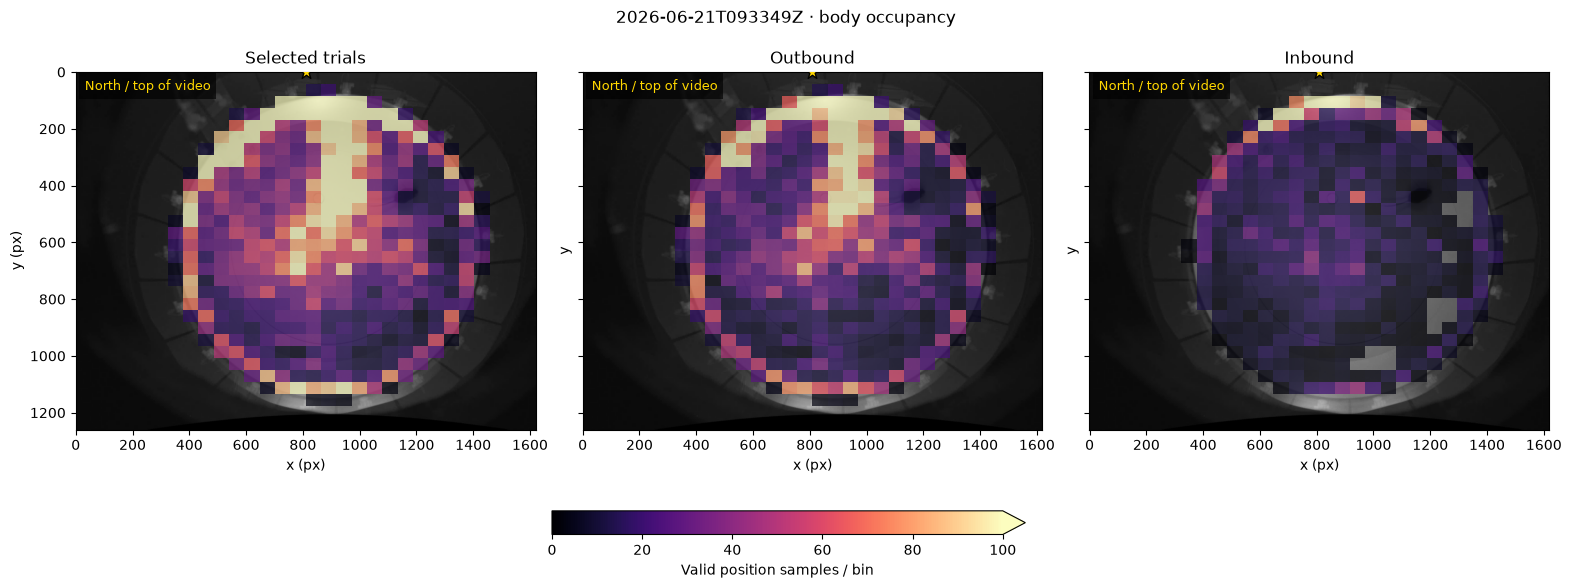

In [8]:
# ===============================================================================
# 8| Select Trial Phases, Then Draw Occupancy from the Prepared Recording Inputs
# ===============================================================================

def select_occupancy_phases(
    point: xr.DataArray, trials: pd.DataFrame,
) -> tuple[dict[str, xr.DataArray], int]:
    """Split already-selected positions at each usable target-trigger time.

    Parameters
    ----------
    point : xarray.DataArray
        One landmark with (time, space) dimensions, recording identity retained
        and excluded trial/window samples already masked to NaN.
    trials : pandas.DataFrame
        Matching selected trial rows with start_time, tz_triggered_time,
        end_time and optional outer endpoint-inclusion flags. Nullable or
        unordered target boundaries cannot contribute to phase masks.

    Returns
    -------
    tuple[dict[str, xarray.DataArray], int]
        Selected-trial, outbound and inbound arrays retaining the original
        clock, plus the number of rows with usable phase boundaries. The target
        sample belongs only to inbound; outer trial endpoint flags are retained.
    """
    outbound = xr.zeros_like(point.time, dtype=bool)
    inbound = xr.zeros_like(point.time, dtype=bool)
    valid_trial_count = 0

    # === 2| Split Each Usable Trial at Its Target-Trigger Time ===================

    for _, trial in trials.iterrows():
        start, target, end = pd.to_numeric(
            pd.Series([trial["start_time"], trial["tz_triggered_time"], trial["end_time"]]),
            errors="coerce",
        ).to_numpy(dtype=float)
        if not np.isfinite([start, target, end]).all() or not start < target < end:
            continue                                                          # A missing or unordered target cannot divide the trial into outbound and inbound portions.

        outbound_trial = trial.copy()
        outbound_trial["end_time"] = target
        outbound_trial["end_inclusive"] = False                               # Target sample goes to inbound; retain the trial's outer start rule.
        inbound_trial = trial.copy()
        inbound_trial["start_time"] = target
        inbound_trial["start_inclusive"] = True                               # Include target; retain the trial's outer end rule.
        outbound_point = slice_stream_for_trial(
            point, outbound_trial, time_coord="time",                         # Match the row to the position array's retained session coordinate.
        )
        inbound_point = slice_stream_for_trial(
            point, inbound_trial, time_coord="time",
        )
        outbound |= point.time.isin(outbound_point.time)
        inbound |= point.time.isin(inbound_point.time)
        valid_trial_count += 1

    points = {
        "Selected trials": point,
        "Outbound": point.where(outbound),
        "Inbound": point.where(inbound),
    }                                                                         # The earlier trial/time selection remains NaN even if a portion's numeric bounds cover it.

    return points, valid_trial_count


def plot_session_occupancy(
    spatial_inputs: dict[str, dict], *, tracking_keypoint: str,
    spatial_unit: str, bins: int = 30, vmax: float | None = None,
    alpha: float = 0.70, arena_range_px_by_session: dict | None = None,
) -> tuple[dict, dict, dict]:
    """Draw phase occupancy over the first frame of each prepared recording.

    Parameters
    ----------
    spatial_inputs : dict[str, dict]
        Outputs of prepare_spatial_sessions including positions, trials, spatial
        scale, first RGB frame, source video path and scaled static ROI.
    tracking_keypoint : str
        Landmark to count in the occupancy histograms.
    spatial_unit : str
        ``px`` or ``cm``, matching the already-scaled position arrays.
    bins : int
        Positive rectangular histogram bin count on each image axis.
    vmax : float | None
        Display ceiling in samples/bin; None uses the recording's observed max.
    alpha : float
        Occupied-bin opacity from zero to one; zero-count bins are transparent.
    arena_range_px_by_session : dict | None
        Optional recording ID -> ((xmin, xmax), (ymin, ymax)) pixel crop. The
        same spatial scale converts crops and image edges to position units.

    Returns
    -------
    tuple[dict, dict, dict]
        Recording ID -> (figure, axes), recording ID -> raw panel histograms,
        and recording ID -> count of trials with usable phase boundaries.
        Frames are reused from preparation; figures are returned without show.
    """
    # === 1| Keep Each Recording's Phase Masks and Image Geometry Together =========
    figures, occupancy_by_session, phase_counts = {}, {}, {}
    ranges = arena_range_px_by_session or {}
    for session_id, selected in spatial_inputs.items():
        point = selected["position"].sel(keypoint=tracking_keypoint, drop=True)
        points, count = select_occupancy_phases(point, selected["trials"])
        scale = selected["spatial_scale"]
        background = selected["background_frame"]
        height, width = background.shape[:2]
        # Half-pixel edges align integer DLC coordinates with image pixel centres.
        extent = tuple(np.array([-0.5, width - 0.5, height - 0.5, -0.5]) * scale)
        crop = ranges.get(session_id)
        arena_range = None if crop is None else tuple(map(tuple, np.asarray(crop) * scale))

        # === 1.1| Draw Matching Panels and Retain Their Unmodified Histograms =====
        figure, axes, occupancy = plot_spatial_occupancy(
            points, background, frame_extent=extent, spatial_unit=spatial_unit,
            fixed_roi=selected["fixed_roi"], fixed_roi_label=selected["fixed_roi_label"],
            bins=bins, arena_range=arena_range, vmax=vmax, alpha=alpha,
            title=f"{session_id} · {tracking_keypoint} occupancy",
        )
        figures[session_id] = (figure, axes)
        occupancy_by_session[session_id] = occupancy
        phase_counts[session_id] = count
        print(f"{session_id}: {count}/{len(selected['trials'])} retained rows have usable target times before the optional window intersection.")
        print("Background:", selected["video_path"], "(first frame)")
        for label, histogram in occupancy.items():
            width = np.diff(histogram["xedges"])[0]
            height = np.diff(histogram["yedges"])[0]
            print(f"{label}: bin width {width:.3g} {spatial_unit}; bin height {height:.3g} {spatial_unit}")
    return figures, occupancy_by_session, phase_counts


# === 9| Draw from the Prepared Arrays Without Reloading Pose or Video =============
occupancy_figures, occupancy_by_session, phase_trial_counts = plot_session_occupancy(
    spatial_inputs, tracking_keypoint=TRACKING_KEYPOINT, spatial_unit=SPATIAL_UNIT,
    bins=OCCUPANCY_BINS, vmax=OCCUPANCY_VMAX, alpha=OCCUPANCY_ALPHA,
    arena_range_px_by_session=ARENA_RANGE_PX_BY_SESSION,
)
plt.show()


Movement reference: [forward-vector angle](https://movement.neuroinformatics.dev/latest/api/movement.kinematics.compute_forward_vector_angle.html), [signed angle](https://movement.neuroinformatics.dev/latest/api/movement.utils.vector.compute_signed_angle_2d.html), [occupancy](https://movement.neuroinformatics.dev/latest/api/movement.plots.plot_occupancy.html).
